In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/python/predictive_maintenance_data.csv')



Mounted at /content/drive


In [3]:
X = df[
    [
        "Tool_Wear_Min",
        "Torque_Nm",
        "Process_Temperature_K",
        "Air_Temperature_K",
        "Rotational_Speed_RPM"
        ]
]

y = df["Machine_Failure"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install imbalanced-learn

In [5]:
from imblearn.over_sampling import SMOTE

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [7]:
import pandas as pd

pd.Series(y_train_smote).value_counts()

,count
Machine_Failure,
0,1072
1,1072


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state = 42,
    class_weight = None
)

model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [14]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [19]:
threshold = 0.30

y_pred_30 = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       268
           1       0.12      0.50      0.20         2

    accuracy                           0.97       270
   macro avg       0.56      0.74      0.59       270
weighted avg       0.99      0.97      0.98       270



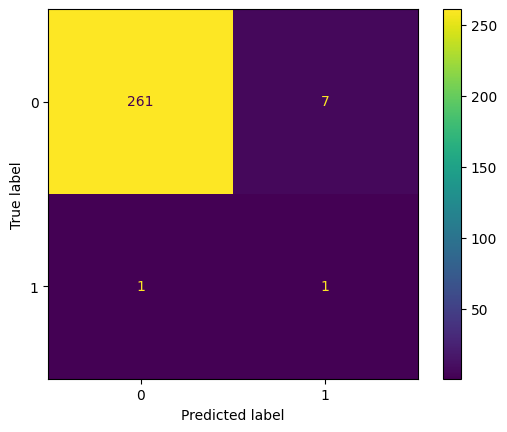

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_30)
plt.show()

In [17]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

                 Feature  Importance
0          Tool_Wear_Min    0.636801
1              Torque_Nm    0.221121
2  Process_Temperature_K    0.057119
4   Rotational_Speed_RPM    0.047844
3      Air_Temperature_K    0.037115


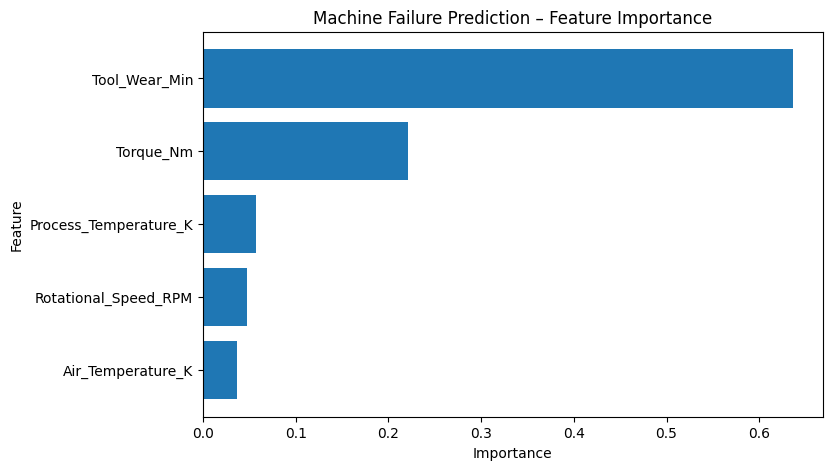

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Machine Failure Prediction – Feature Importance')
plt.gca().invert_yaxis()

plt.show()


In [20]:
df["Predicted_Failure_Probability"] = model.predict_proba(X)[:, 1]

df["Predicted_Failure"] = (
    df["Predicted_Failure_Probability"] >= 0.30
).astype(int)

output_path = "/content/drive/MyDrive/python/predictive_maintenance_predictions.csv"

df.to_csv(output_path, index=False)

print("Predicted dataset saved successfully!")

Predicted dataset saved successfully!
